In [5]:

# =============================================================================
# STAGE 1 + STAGE 2: Merged Pipeline
# Chandipur Tidal Flat Segmentation → Grain-Size Regression
# =============================================================================
# This notebook merges:
#   - Stage 1: DeepLabv3+ and U-Net semantic segmentation (from deeplab.ipynb & U-Net_7_Class_Training.ipynb)
#   - Stage 2: Random Forest grain-size regression using masked spectral values
# =============================================================================

# =====================================================================
# CELL 1: Setup, Configuration, and Data Loaders (SHARED by both models)
# =====================================================================
import os
import rasterio
import numpy as np
import tensorflow as tf
import matplotlib.pyplot as plt
from tensorflow.keras import backend as K
from sklearn.model_selection import train_test_split

print("TensorFlow Version:", tf.__version__)

# --- Configuration ---
IMAGE_DIR = '/Users/SONY/Documents/College/Study_pdeu/Res_Paper/AI/Poojamaam/Data/unet/data/images'
MASK_DIR  = '/Users/SONY/Documents/College/Study_pdeu/Res_Paper/AI/Poojamaam/Data/unet/data/masks'

BATCH_SIZE   = 2
IMG_HEIGHT   = 608
IMG_WIDTH    = 496
NUM_CHANNELS = 5
# 7 real classes + 1 class for the 'No Data' background
NUM_CLASSES  = 8

# --- Data Loader Function ---
def load_and_preprocess(image_path, mask_path):
    image_path = image_path.numpy().decode('utf-8')
    with rasterio.open(image_path) as src:
        image = src.read().astype(np.float32)
        image = np.transpose(image, (1, 2, 0))

    mask_path = mask_path.numpy().decode('utf-8')
    with rasterio.open(mask_path) as src:
        mask = src.read(1).astype(np.uint8)
        # Assign the 'No Data' value (255) to the 'ignore' class (7)
        mask[mask == 255] = 7
        mask = np.expand_dims(mask, axis=-1)

    image = tf.image.resize_with_pad(image, IMG_HEIGHT, IMG_WIDTH)
    mask  = tf.image.resize_with_pad(mask, IMG_HEIGHT, IMG_WIDTH,
                                     method=tf.image.ResizeMethod.NEAREST_NEIGHBOR)
    mask  = tf.squeeze(mask, axis=-1)
    image = image / 65535.0
    mask  = tf.one_hot(tf.cast(mask, tf.uint8), depth=NUM_CLASSES, dtype=tf.float32)
    return image, mask

def create_split_datasets(image_dir, mask_dir):
    image_files = sorted([os.path.join(image_dir, f) for f in os.listdir(image_dir) if f.endswith('.tif')])
    mask_files  = sorted([os.path.join(mask_dir, f)  for f in os.listdir(mask_dir)  if f.endswith('.tif')])
    train_files, test_val_files = train_test_split(
        list(zip(image_files, mask_files)), test_size=0.3, random_state=42)
    val_files, test_files = train_test_split(test_val_files, test_size=0.5, random_state=42)

    def create_tf_dataset(file_list):
        img_paths, msk_paths = zip(*file_list)
        dataset = tf.data.Dataset.from_tensor_slices((list(img_paths), list(msk_paths)))
        dataset = dataset.map(
            lambda img, msk: tf.py_function(load_and_preprocess, [img, msk],
                                            [tf.float32, tf.float32]))
        dataset = dataset.map(lambda img, msk: (
            tf.ensure_shape(img, [IMG_HEIGHT, IMG_WIDTH, NUM_CHANNELS]),
            tf.ensure_shape(msk, [IMG_HEIGHT, IMG_WIDTH, NUM_CLASSES])
        ))
        return dataset

    train_ds = create_tf_dataset(train_files)
    val_ds   = create_tf_dataset(val_files)
    test_ds  = create_tf_dataset(test_files)

    train_ds = train_ds.shuffle(buffer_size=100).batch(BATCH_SIZE).prefetch(tf.data.AUTOTUNE)
    val_ds   = val_ds.batch(BATCH_SIZE).prefetch(tf.data.AUTOTUNE)
    test_ds  = test_ds.batch(BATCH_SIZE).prefetch(tf.data.AUTOTUNE)
    return train_ds, val_ds, test_ds

# Create the datasets
train_dataset, val_dataset, test_dataset = create_split_datasets(IMAGE_DIR, MASK_DIR)
print("✅ Datasets created successfully!")


TensorFlow Version: 2.19.0
✅ Datasets created successfully!



## Stage 1A: U-Net Model Architecture
Build the U-Net segmentation model (from `U-Net_7_Class_Training.ipynb`).


In [6]:

# =====================================================================
# CELL 2: U-Net Model Architecture
# =====================================================================
from tensorflow.keras.models import Model
from tensorflow.keras.layers import (Input, Conv2D, MaxPooling2D,
                                     Conv2DTranspose, concatenate)

def build_unet(input_shape, num_classes):
    inputs = Input(input_shape)
    # Encoder
    c1 = Conv2D(16, (3,3), activation='relu', kernel_initializer='he_normal', padding='same')(inputs)
    c1 = Conv2D(16, (3,3), activation='relu', kernel_initializer='he_normal', padding='same')(c1)
    p1 = MaxPooling2D((2,2))(c1)

    c2 = Conv2D(32, (3,3), activation='relu', kernel_initializer='he_normal', padding='same')(p1)
    c2 = Conv2D(32, (3,3), activation='relu', kernel_initializer='he_normal', padding='same')(c2)
    p2 = MaxPooling2D((2,2))(c2)

    c3 = Conv2D(64, (3,3), activation='relu', kernel_initializer='he_normal', padding='same')(p2)
    c3 = Conv2D(64, (3,3), activation='relu', kernel_initializer='he_normal', padding='same')(c3)
    p3 = MaxPooling2D((2,2))(c3)

    c4 = Conv2D(128, (3,3), activation='relu', kernel_initializer='he_normal', padding='same')(p3)
    c4 = Conv2D(128, (3,3), activation='relu', kernel_initializer='he_normal', padding='same')(c4)
    p4 = MaxPooling2D((2,2))(c4)

    # Bottleneck
    c5 = Conv2D(256, (3,3), activation='relu', kernel_initializer='he_normal', padding='same')(p4)
    c5 = Conv2D(256, (3,3), activation='relu', kernel_initializer='he_normal', padding='same')(c5)

    # Decoder
    u6 = Conv2DTranspose(128, (2,2), strides=(2,2), padding='same')(c5)
    u6 = concatenate([u6, c4])
    c6 = Conv2D(128, (3,3), activation='relu', kernel_initializer='he_normal', padding='same')(u6)
    c6 = Conv2D(128, (3,3), activation='relu', kernel_initializer='he_normal', padding='same')(c6)

    u7 = Conv2DTranspose(64, (2,2), strides=(2,2), padding='same')(c6)
    u7 = concatenate([u7, c3])
    c7 = Conv2D(64, (3,3), activation='relu', kernel_initializer='he_normal', padding='same')(u7)
    c7 = Conv2D(64, (3,3), activation='relu', kernel_initializer='he_normal', padding='same')(c7)

    u8 = Conv2DTranspose(32, (2,2), strides=(2,2), padding='same')(c7)
    u8 = concatenate([u8, c2])
    c8 = Conv2D(32, (3,3), activation='relu', kernel_initializer='he_normal', padding='same')(u8)
    c8 = Conv2D(32, (3,3), activation='relu', kernel_initializer='he_normal', padding='same')(c8)

    u9 = Conv2DTranspose(16, (2,2), strides=(2,2), padding='same')(c8)
    u9 = concatenate([u9, c1])
    c9 = Conv2D(16, (3,3), activation='relu', kernel_initializer='he_normal', padding='same')(u9)
    c9 = Conv2D(16, (3,3), activation='relu', kernel_initializer='he_normal', padding='same')(c9)

    outputs = Conv2D(num_classes, (1,1), activation='softmax')(c9)
    model = Model(inputs=[inputs], outputs=[outputs])
    return model

input_shape = (IMG_HEIGHT, IMG_WIDTH, NUM_CHANNELS)
unet_model = build_unet(input_shape, NUM_CLASSES)
print("✅ U-Net model built.")
unet_model.summary()


✅ U-Net model built.


Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer         │ (None, 608, 496,  │          0 │ -                 │
│ (InputLayer)        │ 5)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d (Conv2D)     │ (None, 608, 496,  │        736 │ input_layer[0][0] │
│                     │ 16)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_1 (Conv2D)   │ (None, 608, 496,  │      2,320 │ conv2d[0][0]      │
│                     │ 16)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ max_pooling2d       │ (None, 304, 248,  │          0 │ conv2d_1[0][0]    │
│ (MaxPooling2D)      │ 16)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_2 (Conv2D)   │ (None, 304, 248,  │      4,640 │ max_pooling2d[0]… │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_3 (Conv2D)   │ (None, 304, 248,  │      9,248 │ conv2d_2[0][0]    │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ max_pooling2d_1     │ (None, 152, 124,  │          0 │ conv2d_3[0][0]    │
│ (MaxPooling2D)      │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_4 (Conv2D)   │ (None, 152, 124,  │     18,496 │ max_pooling2d_1[… │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_5 (Conv2D)   │ (None, 152, 124,  │     36,928 │ conv2d_4[0][0]    │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ max_pooling2d_2     │ (None, 76, 62,    │          0 │ conv2d_5[0][0]    │
│ (MaxPooling2D)      │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_6 (Conv2D)   │ (None, 76, 62,    │     73,856 │ max_pooling2d_2[… │
│                     │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_7 (Conv2D)   │ (None, 76, 62,    │    147,584 │ conv2d_6[0][0]    │
│                     │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ max_pooling2d_3     │ (None, 38, 31,    │          0 │ conv2d_7[0][0]    │
│ (MaxPooling2D)      │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_8 (Conv2D)   │ (None, 38, 31,    │    295,168 │ max_pooling2d_3[… │
│                     │ 256)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_9 (Conv2D)   │ (None, 38, 31,    │    590,080 │ conv2d_8[0][0]    │
│                     │ 256)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_transpose    │ (None, 76, 62,    │    131,200 │ conv2d_9[0][0]    │
│ (Conv2DTranspose)   │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ concatenate         │ (None, 76, 62,    │          0 │ conv2d_transpose

 Total params: 1,941,512 (7.41 MB)

 Trainable params: 1,941,512 (7.41 MB)

 Non-trainable params: 0 (0.00 B)


## Stage 1B: DeepLabv3+ Model Architecture
Build the DeepLabv3+ segmentation model (from `deeplab.ipynb`).


In [7]:

# =====================================================================
# CELL 3: DeepLabv3+ Model Architecture
# =====================================================================
from tensorflow.keras.layers import (Input, Conv2D, BatchNormalization, ReLU,
                                     GlobalAveragePooling2D, UpSampling2D,
                                     Concatenate, Lambda)
from tensorflow.keras.models import Model
from tensorflow.keras.applications import MobileNetV2

def aspp_block(inputs, num_filters):
    """Atrous Spatial Pyramid Pooling block"""
    _, H, W, _ = inputs.shape

    conv_1x1 = Conv2D(num_filters, (1,1), padding="same", use_bias=False)(inputs)
    conv_1x1 = BatchNormalization()(conv_1x1)
    conv_1x1 = ReLU()(conv_1x1)

    conv_3x3_rate6 = Conv2D(num_filters, (3,3), padding="same", dilation_rate=6, use_bias=False)(inputs)
    conv_3x3_rate6 = BatchNormalization()(conv_3x3_rate6)
    conv_3x3_rate6 = ReLU()(conv_3x3_rate6)

    conv_3x3_rate12 = Conv2D(num_filters, (3,3), padding="same", dilation_rate=12, use_bias=False)(inputs)
    conv_3x3_rate12 = BatchNormalization()(conv_3x3_rate12)
    conv_3x3_rate12 = ReLU()(conv_3x3_rate12)

    conv_3x3_rate18 = Conv2D(num_filters, (3,3), padding="same", dilation_rate=18, use_bias=False)(inputs)
    conv_3x3_rate18 = BatchNormalization()(conv_3x3_rate18)
    conv_3x3_rate18 = ReLU()(conv_3x3_rate18)

    image_pool = GlobalAveragePooling2D()(inputs)
    image_pool = Lambda(lambda x: K.expand_dims(K.expand_dims(x, 1), 1))(image_pool)
    image_pool = Conv2D(num_filters, (1,1), use_bias=False)(image_pool)
    image_pool = BatchNormalization()(image_pool)
    image_pool = ReLU()(image_pool)
    image_pool = UpSampling2D(size=(H, W), interpolation="bilinear")(image_pool)

    concatenated = Concatenate()([conv_1x1, conv_3x3_rate6, conv_3x3_rate12,
                                  conv_3x3_rate18, image_pool])
    final_conv = Conv2D(num_filters, (1,1), padding="same", use_bias=False)(concatenated)
    final_conv = BatchNormalization()(final_conv)
    final_conv = ReLU()(final_conv)
    return final_conv

def build_deeplabv3plus(input_shape, num_classes):
    """Builds DeepLabv3+ with a 5-channel input adapter"""
    true_input = Input(shape=input_shape)
    adapted_input = Conv2D(3, (1,1), padding='same', name='input_adapter')(true_input)

    base_model = MobileNetV2(
        input_shape=(input_shape[0], input_shape[1], 3),
        include_top=False, weights='imagenet')
    base_model.trainable = False

    high_level_layer = base_model.get_layer('block_13_expand_relu')
    low_level_layer  = base_model.get_layer('block_3_expand_relu')

    feature_extractor = Model(inputs=base_model.input,
                              outputs=[low_level_layer.output, high_level_layer.output])
    low_level_features, high_level_features = feature_extractor(adapted_input)

    aspp_output = aspp_block(high_level_features, 256)
    aspp_output_upsampled = UpSampling2D(size=(4,4), interpolation="bilinear")(aspp_output)

    low_level_projected = Conv2D(48, (1,1), padding="same", use_bias=False)(low_level_features)
    low_level_projected = BatchNormalization()(low_level_projected)
    low_level_projected = ReLU()(low_level_projected)

    decoder_output = Concatenate()([aspp_output_upsampled, low_level_projected])
    decoder_output = Conv2D(256, (3,3), padding="same", use_bias=False)(decoder_output)
    decoder_output = BatchNormalization()(decoder_output)
    decoder_output = ReLU()(decoder_output)
    decoder_output = Conv2D(256, (3,3), padding="same", use_bias=False)(decoder_output)
    decoder_output = BatchNormalization()(decoder_output)
    decoder_output = ReLU()(decoder_output)

    final_output = UpSampling2D(size=(4,4), interpolation="bilinear")(decoder_output)
    final_output = Conv2D(num_classes, (1,1), activation='softmax')(final_output)

    model = Model(inputs=true_input, outputs=final_output)
    return model

deeplab_model = build_deeplabv3plus(input_shape, NUM_CLASSES)
print("✅ DeepLabv3+ model built.")
deeplab_model.summary()


/var/folders/6m/c1kddlqx7c1fsv7ny307m4580000gn/T/ipykernel_1270/2807547701.py:49: UserWarning: `input_shape` is undefined or non-square, or `rows` is not in [96, 128, 160, 192, 224]. Weights for input shape (224, 224) will be loaded as the default.
  base_model = MobileNetV2(


✅ DeepLabv3+ model built.


Model: "functional_2"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer_1       │ (None, 608, 496,  │          0 │ -                 │
│ (InputLayer)        │ 5)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ input_adapter       │ (None, 608, 496,  │         18 │ input_layer_1[0]… │
│ (Conv2D)            │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ functional_1        │ [(None, 152, 124, │    616,256 │ input_adapter[0]… │
│ (Functional)        │ 144), (None, 38,  │            │                   │
│                     │ 31, 576)]         │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ global_average_poo… │ (None, 576)       │          0 │ functional_1[0][… │
│ (GlobalAveragePool… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ lambda (Lambda)     │ (None, 1, 1, 576) │          0 │ global_average_p… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_23 (Conv2D)  │ (None, 1, 1, 256) │    147,456 │ lambda[0][0]      │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_19 (Conv2D)  │ (None, 38, 31,    │    147,456 │ functional_1[0][… │
│                     │ 256)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_20 (Conv2D)  │ (None, 38, 31,    │  1,327,104 │ functional_1[0][… │
│                     │ 256)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_21 (Conv2D)  │ (None, 38, 31,    │  1,327,104 │ functional_1[0][… │
│                     │ 256)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_22 (Conv2D)  │ (None, 38, 31,    │  1,327,104 │ functional_1[0][… │
│                     │ 256)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 1, 1, 256) │      1,024 │ conv2d_23[0][0]   │
│ (BatchNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalization │ (None, 38, 31,    │      1,024 │ conv2d_19[0][0]   │
│ (BatchNormalizatio… │ 256)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 38, 31,    │      1,024 │ conv2d_20[0][0]   │
│ (BatchNormalizatio… │ 256)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 38, 31,    │      1,024 │ conv2d_21[0][0]   │
│ (BatchNormalizatio… │ 256)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 38, 31,    │      1,024 │ conv2d_22[0][0]   │
│ (BatchNormalizatio… │ 256)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ re_lu_4 (ReLU)      │ (None, 1, 1, 256) │          0 │ batch_normalizat… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ re_lu (ReLU)        │ (None, 38, 31,    │          0 │ batch_normalizat… │
│                     │ 256)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼─────────────────

 Total params: 6,527,770 (24.90 MB)

 Trainable params: 5,907,322 (22.53 MB)

 Non-trainable params: 620,448 (2.37 MB)


## Stage 1C: Custom Loss Function (Shared) + Compile & Train Both Models


In [8]:

# =====================================================================
# CELL 4: Custom Loss Function (ignores NoData class) — Shared
# =====================================================================
def dice_loss(y_true, y_pred, smooth=1e-6):
    y_pred = tf.cast(y_pred, dtype=tf.float32)
    y_true = tf.cast(y_true, dtype=tf.float32)
    # Exclude the last 'ignore' class
    y_pred_valid = y_pred[:,:,:,:-1]
    y_true_valid = y_true[:,:,:,:-1]
    intersection = K.sum(y_true_valid * y_pred_valid, axis=[1, 2, 3])
    union = K.sum(y_true_valid, axis=[1, 2, 3]) + K.sum(y_pred_valid, axis=[1, 2, 3])
    dice = K.mean((2. * intersection + smooth) / (union + smooth), axis=0)
    return 1 - dice

def focal_loss(y_true, y_pred, gamma=2.0, alpha=0.25):
    y_pred = tf.cast(y_pred, dtype=tf.float32)
    y_true = tf.cast(y_true, dtype=tf.float32)
    y_pred_valid = y_pred[:,:,:,:-1]
    y_true_valid = y_true[:,:,:,:-1]
    epsilon = K.epsilon()
    y_pred_valid = K.clip(y_pred_valid, epsilon, 1. - epsilon)
    cross_entropy = -y_true_valid * K.log(y_pred_valid)
    loss = alpha * K.pow(1 - y_pred_valid, gamma) * cross_entropy
    return K.mean(K.sum(loss, axis=-1))

def combined_loss(y_true, y_pred):
    return focal_loss(y_true, y_pred) + dice_loss(y_true, y_pred)

print("✅ Custom loss function (ignores NoData class) defined.")


✅ Custom loss function (ignores NoData class) defined.


In [19]:

# =====================================================================
# CELL 5: Compile and Train BOTH Models
# =====================================================================
EPOCHS        = 45
LEARNING_RATE = 0.0005

# --- Train U-Net ---
print("=" * 60)
print("🔷 Training U-Net Model")
print("=" * 60)
unet_model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=LEARNING_RATE),
    loss=combined_loss,
    metrics=['accuracy', tf.keras.metrics.MeanIoU(num_classes=NUM_CLASSES)]
)
unet_history = unet_model.fit(
    train_dataset, epochs=EPOCHS, validation_data=val_dataset
)
print("✅ U-Net training finished!")

# --- Train DeepLabv3+ ---
print("\n" + "=" * 60)
print("🔷 Training DeepLabv3+ Model")
print("=" * 60)
deeplab_model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=LEARNING_RATE),
    loss=combined_loss,
    metrics=['accuracy', tf.keras.metrics.MeanIoU(num_classes=NUM_CLASSES)]
)
deeplab_history = deeplab_model.fit(
    train_dataset, epochs=EPOCHS, validation_data=val_dataset
)
print("✅ DeepLabv3+ training finished!")


🔷 Training U-Net Model
Epoch 1/45


/opt/miniconda3/envs/tf_env/lib/python3.12/site-packages/keras/src/models/functional.py:238: UserWarning: The structure of `inputs` doesn't match the expected structure.
Expected: ['keras_tensor']
Received: inputs=Tensor(shape=(None, 608, 496, 5))
  warnings.warn(msg)


5/5 ━━━━━━━━━━━━━━━━━━━━ 10s 1s/step - accuracy: 0.8418 - loss: 0.2514 - mean_io_u_2: 0.6981 - val_accuracy: 0.8244 - val_loss: 0.2826 - val_mean_io_u_2: 0.7756
Epoch 2/45
5/5 ━━━━━━━━━━━━━━━━━━━━ 10s 1s/step - accuracy: 0.8418 - loss: 0.2514 - mean_io_u_2: 0.6981 - val_accuracy: 0.8244 - val_loss: 0.2826 - val_mean_io_u_2: 0.7756
Epoch 2/45
5/5 ━━━━━━━━━━━━━━━━━━━━ 9s 2s/step - accuracy: 0.8249 - loss: 0.2635 - mean_io_u_2: 0.7432 - val_accuracy: 0.8334 - val_loss: 0.2422 - val_mean_io_u_2: 0.6477
Epoch 3/45
5/5 ━━━━━━━━━━━━━━━━━━━━ 9s 2s/step - accuracy: 0.8249 - loss: 0.2635 - mean_io_u_2: 0.7432 - val_accuracy: 0.8334 - val_loss: 0.2422 - val_mean_io_u_2: 0.6477
Epoch 3/45
5/5 ━━━━━━━━━━━━━━━━━━━━ 9s 2s/step - accuracy: 0.8305 - loss: 0.2489 - mean_io_u_2: 0.6891 - val_accuracy: 0.8371 - val_loss: 0.2377 - val_mean_io_u_2: 0.7729
Epoch 4/45
5/5 ━━━━━━━━━━━━━━━━━━━━ 9s 2s/step - accuracy: 0.8305 - loss: 0.2489 - mean_io_u_2: 0.6891 - val_accuracy: 0.8371 - val_loss: 0.2377 - val_mea

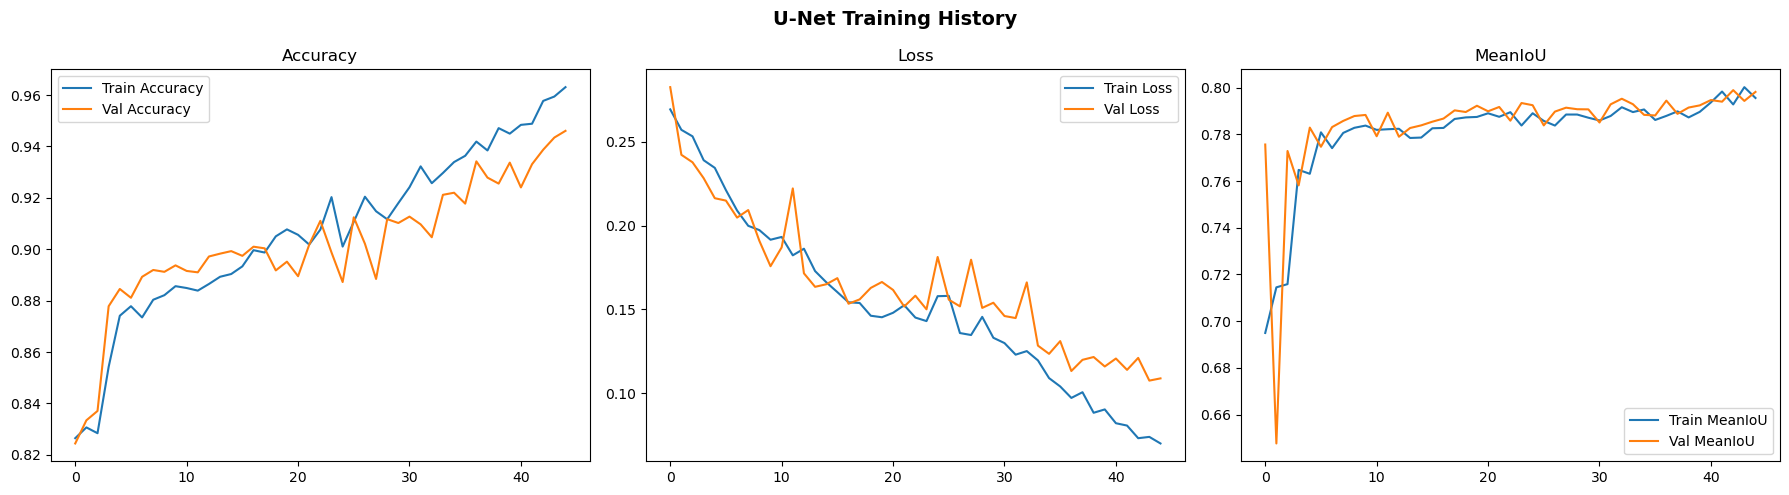

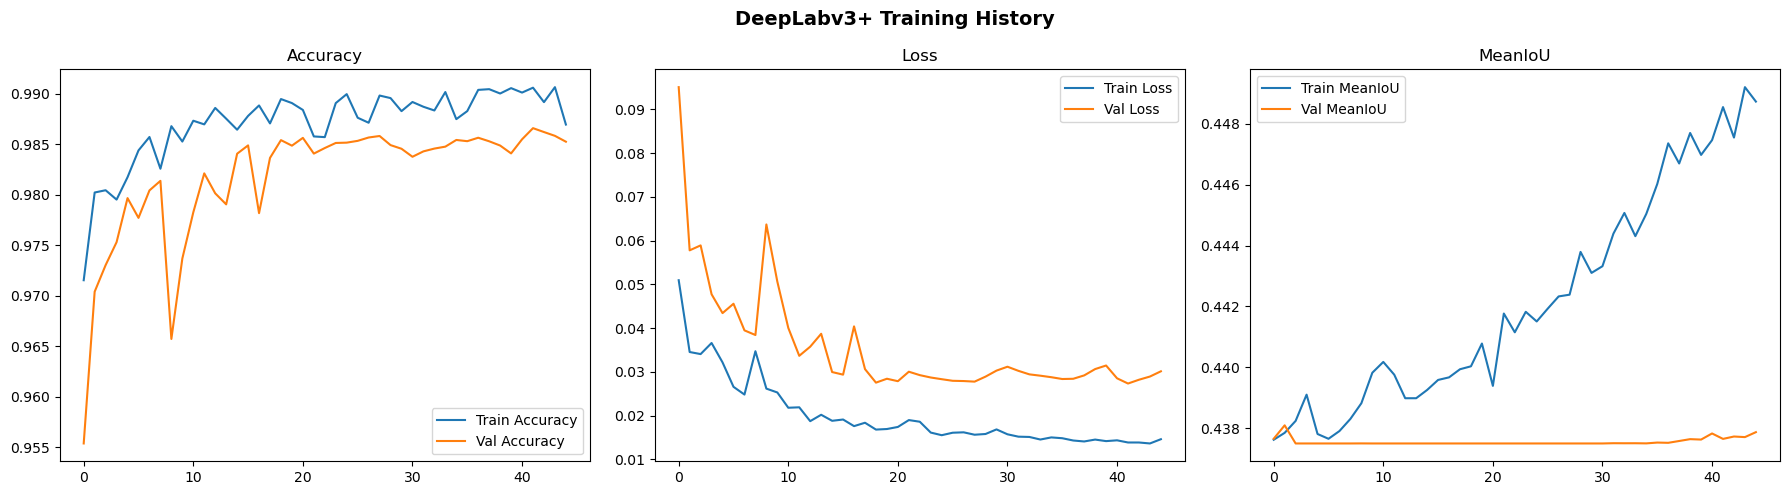

In [20]:

# =====================================================================
# CELL 6: Training History Visualization (Side by Side)
# =====================================================================
def plot_history(history, model_name):
    """Plot accuracy, loss, and MeanIoU for a model's training history."""
    acc     = history.history['accuracy']
    val_acc = history.history['val_accuracy']
    loss    = history.history['loss']
    val_loss= history.history['val_loss']

    # Dynamically find the MeanIoU key
    all_keys = history.history.keys()
    iou_key = [k for k in all_keys if 'mean_io' in k and 'val' not in k]
    if iou_key:
        mean_iou     = history.history[iou_key[0]]
        val_mean_iou = history.history[f'val_{iou_key[0]}']
    else:
        mean_iou = val_mean_iou = None

    epochs_range = range(len(acc))
    n_plots = 3 if mean_iou else 2

    plt.figure(figsize=(6 * n_plots, 5))
    plt.suptitle(f'{model_name} Training History', fontsize=14, fontweight='bold')

    plt.subplot(1, n_plots, 1)
    plt.plot(epochs_range, acc, label='Train Accuracy')
    plt.plot(epochs_range, val_acc, label='Val Accuracy')
    plt.legend(); plt.title('Accuracy')

    plt.subplot(1, n_plots, 2)
    plt.plot(epochs_range, loss, label='Train Loss')
    plt.plot(epochs_range, val_loss, label='Val Loss')
    plt.legend(); plt.title('Loss')

    if mean_iou:
        plt.subplot(1, n_plots, 3)
        plt.plot(epochs_range, mean_iou, label='Train MeanIoU')
        plt.plot(epochs_range, val_mean_iou, label='Val MeanIoU')
        plt.legend(); plt.title('MeanIoU')

    plt.tight_layout()
    plt.show()

plot_history(unet_history, "U-Net")
plot_history(deeplab_history, "DeepLabv3+")


/opt/miniconda3/envs/tf_env/lib/python3.12/site-packages/keras/src/models/functional.py:238: UserWarning: The structure of `inputs` doesn't match the expected structure.
Expected: ['keras_tensor']
Received: inputs=Tensor(shape=(2, 608, 496, 5))
  warnings.warn(msg)



📊 Evaluation: U-Net


2026-03-08 01:18:23.517640: I tensorflow/core/framework/local_rendezvous.cc:407] Local rendezvous is aborting with status: OUT_OF_RANGE: End of sequence


              precision    recall  f1-score   support

        TFNS       0.98      0.97      0.98    648264
        TFAS       0.80      0.75      0.77     46253
  Vegetation       0.69      0.92      0.78     30849
 Sandy beach       0.75      0.43      0.55     13964
Agri Patches       0.88      0.99      0.93     61574
  Aqua Ponds       0.89      0.58      0.70     17335
       Water       0.91      0.96      0.93     86465

    accuracy                           0.94    904704
   macro avg       0.84      0.80      0.81    904704
weighted avg       0.95      0.94      0.94    904704

Cohen's Kappa: 0.8799


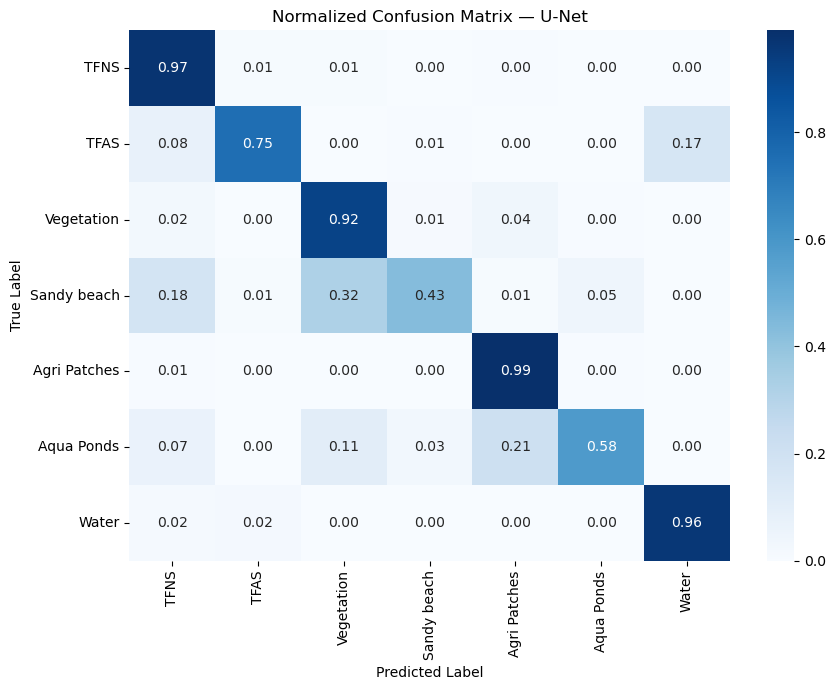


📊 Evaluation: DeepLabv3+
              precision    recall  f1-score   support

        TFNS       0.99      0.99      0.99    648264
        TFAS       0.92      0.96      0.94     46253
  Vegetation       0.89      0.99      0.93     30849
 Sandy beach       0.91      0.78      0.84     13964
Agri Patches       0.99      1.00      0.99     61574
  Aqua Ponds       0.99      0.99      0.99     17335
       Water       0.98      0.98      0.98     86465

    accuracy                           0.98    904704
   macro avg       0.95      0.95      0.95    904704
weighted avg       0.98      0.98      0.98    904704

Cohen's Kappa: 0.9635


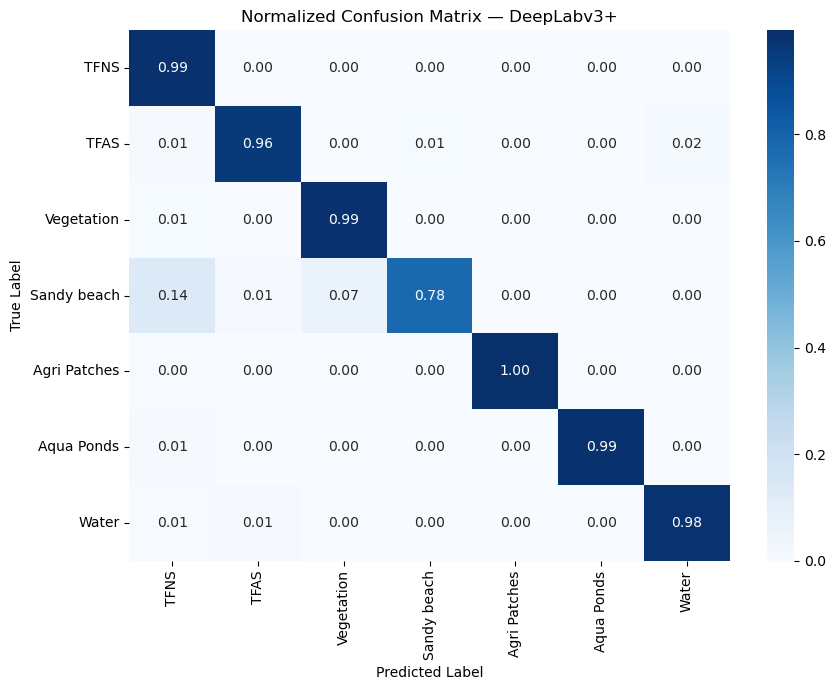

In [21]:

# =====================================================================
# CELL 7: Evaluate Both Models on Test Set — Confusion Matrix, Kappa, Reports
# =====================================================================
from sklearn.metrics import (classification_report, confusion_matrix,
                             cohen_kappa_score)
import seaborn as sns

class_names_7 = ['TFNS', 'TFAS', 'Vegetation', 'Sandy beach',
                 'Agri Patches', 'Aqua Ponds', 'Water']

def evaluate_model(model, test_dataset, model_name):
    """Full evaluation: per-class report, confusion matrix, kappa."""
    all_true, all_pred = [], []
    for images, masks in test_dataset:
        preds = model.predict(images, verbose=0)
        all_pred.append(np.argmax(preds, axis=-1))
        all_true.append(np.argmax(masks.numpy(), axis=-1))

    y_true = np.concatenate(all_true).flatten()
    y_pred = np.concatenate(all_pred).flatten()

    # Filter out NoData pixels (class 7) from evaluation
    valid_mask = y_true < 7
    y_true = y_true[valid_mask]
    y_pred = y_pred[valid_mask]

    print(f"\n{'='*60}")
    print(f"📊 Evaluation: {model_name}")
    print(f"{'='*60}")

    # Classification report
    print(classification_report(y_true, y_pred, target_names=class_names_7,
                                labels=list(range(7))))

    # Kappa
    kappa = cohen_kappa_score(y_true, y_pred)
    print(f"Cohen's Kappa: {kappa:.4f}")

    # Confusion Matrix
    cm = confusion_matrix(y_true, y_pred, labels=list(range(7)))
    cm_norm = cm.astype('float') / cm.sum(axis=1, keepdims=True)
    plt.figure(figsize=(9, 7))
    sns.heatmap(cm_norm, annot=True, fmt=".2f", cmap="Blues",
                xticklabels=class_names_7, yticklabels=class_names_7)
    plt.title(f'Normalized Confusion Matrix — {model_name}')
    plt.ylabel('True Label'); plt.xlabel('Predicted Label')
    plt.tight_layout(); plt.show()

    return y_true, y_pred

y_true_unet, y_pred_unet       = evaluate_model(unet_model, test_dataset, "U-Net")
y_true_deeplab, y_pred_deeplab  = evaluate_model(deeplab_model, test_dataset, "DeepLabv3+")


1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 284ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 284ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 744ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 744ms/step


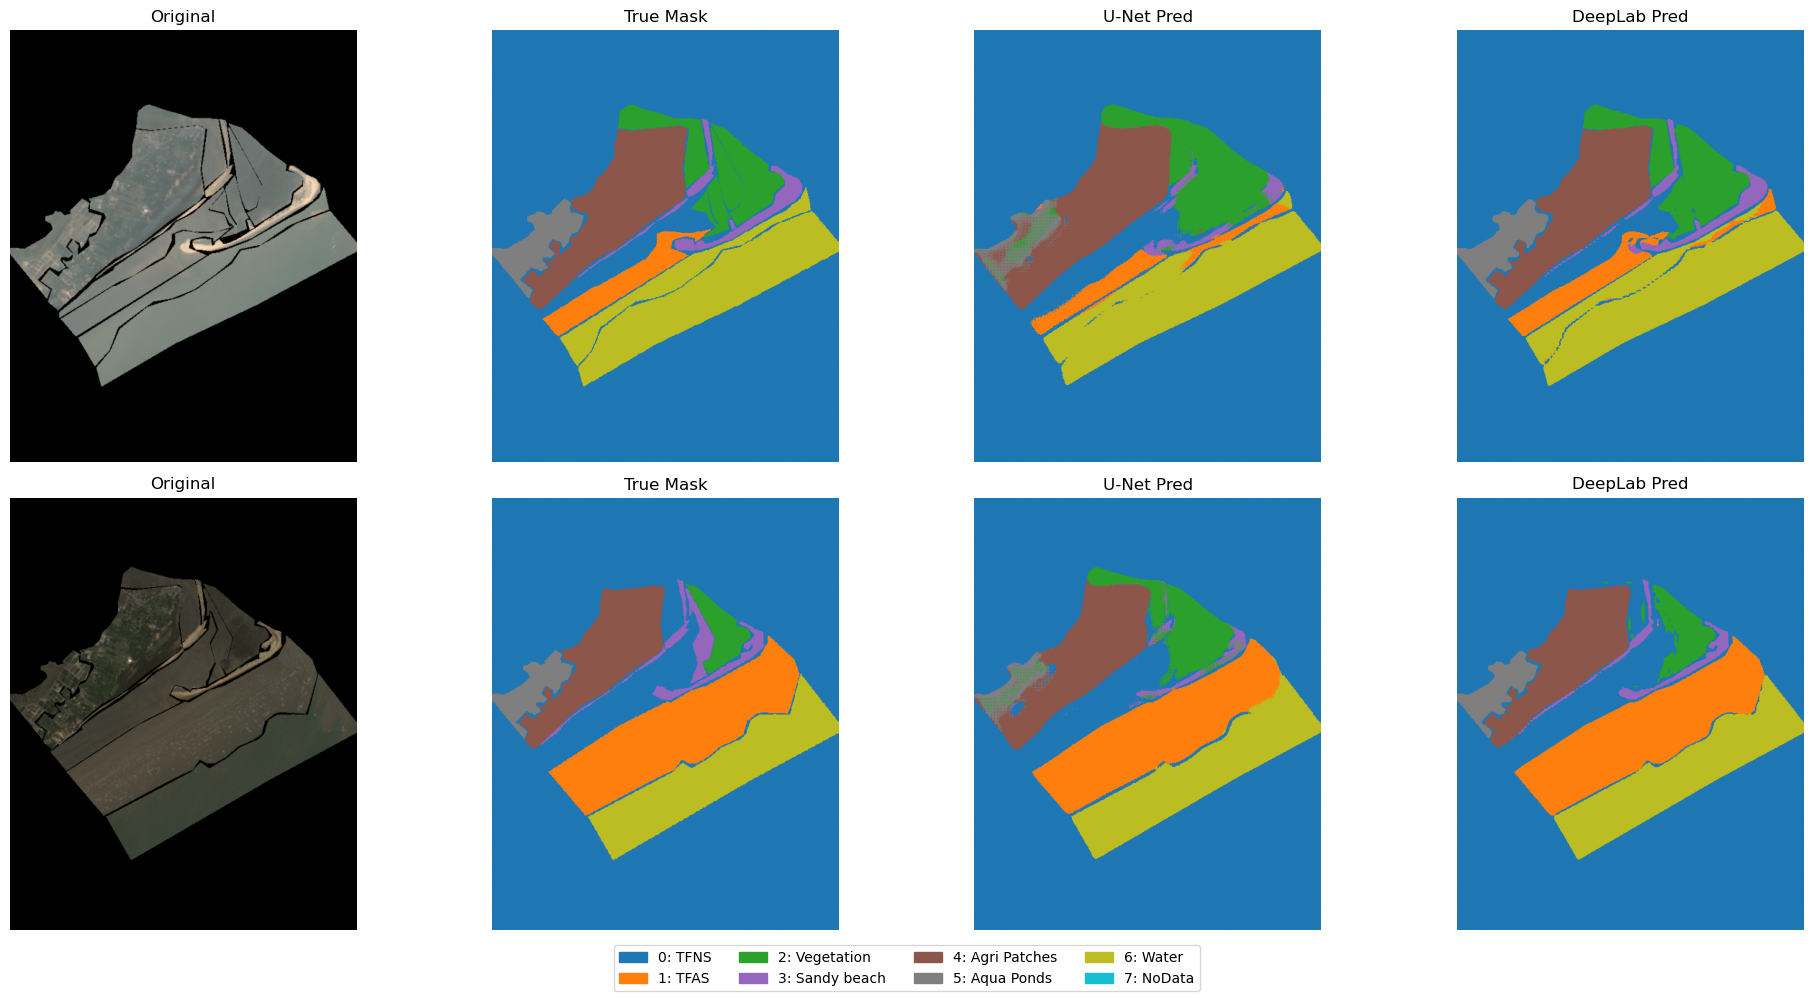

In [22]:

# =====================================================================
# CELL 8: Visualize Predictions (Both Models Side-by-Side)
# =====================================================================
import matplotlib.patches as mpatches

class_names_display = [
    "0: TFNS", "1: TFAS", "2: Vegetation", "3: Sandy beach",
    "4: Agri Patches", "5: Aqua Ponds", "6: Water", "7: NoData"
]
cmap = plt.get_cmap('tab10', NUM_CLASSES)

for images, masks in test_dataset.take(1):
    unet_preds   = np.argmax(unet_model.predict(images), axis=-1)
    deeplab_preds = np.argmax(deeplab_model.predict(images), axis=-1)
    true_masks   = np.argmax(masks.numpy(), axis=-1)

num_to_display = min(len(images), 3)
fig, axes = plt.subplots(num_to_display, 4, figsize=(20, 5 * num_to_display))
if num_to_display == 1:
    axes = axes[np.newaxis, :]

for i in range(num_to_display):
    original_h, original_w = 601, 482
    h_pad = (IMG_HEIGHT - original_h) // 2
    w_pad = (IMG_WIDTH  - original_w) // 2

    img_crop  = images[i][h_pad:h_pad+original_h, w_pad:w_pad+original_w, :]
    true_crop = true_masks[i][h_pad:h_pad+original_h, w_pad:w_pad+original_w]
    unet_crop = unet_preds[i][h_pad:h_pad+original_h, w_pad:w_pad+original_w]
    deep_crop = deeplab_preds[i][h_pad:h_pad+original_h, w_pad:w_pad+original_w]

    rgb = img_crop.numpy()[:, :, [2, 1, 0]]
    rgb = (rgb - rgb.min()) / (rgb.max() - rgb.min() + 1e-6)

    axes[i, 0].imshow(rgb);           axes[i, 0].set_title("Original"); axes[i, 0].axis("off")
    axes[i, 1].imshow(true_crop, cmap=cmap, vmin=0, vmax=7); axes[i, 1].set_title("True Mask"); axes[i, 1].axis("off")
    axes[i, 2].imshow(unet_crop, cmap=cmap, vmin=0, vmax=7); axes[i, 2].set_title("U-Net Pred"); axes[i, 2].axis("off")
    axes[i, 3].imshow(deep_crop, cmap=cmap, vmin=0, vmax=7); axes[i, 3].set_title("DeepLab Pred"); axes[i, 3].axis("off")

legend_patches = [mpatches.Patch(color=cmap(i), label=class_names_display[i]) for i in range(NUM_CLASSES)]
fig.legend(handles=legend_patches, loc='lower center', ncol=4, fontsize=10)
plt.tight_layout(rect=[0, 0.05, 1, 1])
plt.show()


In [23]:

# =====================================================================
# CELL 9: Save Both Trained Models
# =====================================================================
unet_model.save('unet_chandipur_7class.h5')
print("✅ U-Net model saved to 'unet_chandipur_7class.h5'")

deeplab_model.save('deeplab_chandipur_7class.h5')
print("✅ DeepLabv3+ model saved to 'deeplab_chandipur_7class.h5'")


✅ U-Net model saved to 'unet_chandipur_7class.h5'
✅ DeepLabv3+ model saved to 'deeplab_chandipur_7class.h5'


---
# ═══════════════════════════════════════════════════════════════
# STAGE 2: Grain-Size Regression using Random Forest
# ═══════════════════════════════════════════════════════════════
#
# **As per the ICICV paper (Section 4.2):**
# > "Pixels classified as Tidal Flat Near Shore (TFNS), Tidal Flat Away Shore (TFAS),
# > or Sandy Beach by Stage 1 are passed to Stage 2."
#
# **Pipeline:**
# 1. Use Stage 1 segmentation masks to identify tidal-flat pixels (TFNS=0, TFAS=1, Sandy Beach=3)
# 2. Filter in-situ samples to **only TFNS, TFAS, and Beach** sub-environments
# 3. Extract Sentinel-2 spectral reflectance (B2, B3, B4, B8, B11) at those sample locations
# 4. Train a Random Forest Regressor with Leave-One-Out Cross-Validation (LOOCV)
# 5. Evaluate with RMSE, R², and feature importance analysis
# 6. Apply the model spatially to generate a grain-size prediction map

In [24]:
# =====================================================================
# CELL 10: Stage 2 — Load In-Situ Sample Locations (TFNS, TFAS, Beach only)
# =====================================================================
# As per the ICICV paper (Sec. 4.2): only TFNS, TFAS, and Sandy Beach
# samples are used for the grain-size regression stage.
# =====================================================================
import pandas as pd
import glob
from pyproj import Transformer

# ------------------------------------------------------------------
# 10a. Load sample locations from the CSV files
# ------------------------------------------------------------------
DOCS_DIR = '/Users/SONY/Documents/College/Study_pdeu/Res_Paper/AI/Poojamaam/Docs'

df_2017 = pd.read_csv(os.path.join(DOCS_DIR, 'chandipur_locations_2017.csv'))
df_2018 = pd.read_csv(os.path.join(DOCS_DIR, 'chandipur_locations_2018.csv'))
df_2020 = pd.read_csv(os.path.join(DOCS_DIR, 'chandipur_locations_2020.csv'))

# Combine all years
grain_size_data_all = pd.concat([df_2017, df_2018, df_2020], ignore_index=True)

# Add a sample ID column matching the lab sample numbers
sample_ids_2017 = ['A33', 'A37',                              # TFNS (2)
                   'A27', 'A39', 'A41', 'A45', 'A47',         # TFAS (5)
                   'A10', 'A11', 'A15', 'A19', 'A21',         # BBM (5)
                   'A51',                                      # EM (1)
                   'A2', 'A17', 'A23', 'A29', 'A30', 'A7']    # Beach (6)

sample_ids_2018 = ['B7', 'B9', 'B13', 'B15', 'B17', 'B22', 'B26',  # TFNS (7)
                   'B1', 'B3', 'B24',                                # TFAS (3)
                   'B21']                                             # EM (1)

sample_ids_2020 = ['C1', 'C2', 'C4',       # TFNS (3)
                   'C5', 'C6', 'C7',       # BBM (3)
                   'C3',                    # Creek (1)
                   'C8']                    # Beach (1)

grain_size_data_all['Sample_ID'] = sample_ids_2017 + sample_ids_2018 + sample_ids_2020

# Shorten sub-environment names
env_map = {
    'Tidal Flat Near Shoreline (TFNS)': 'TFNS',
    'Tidal Flat Away from Shoreline (TFAS)': 'TFAS',
    'Back Barrier Marsh (BBM)': 'BBM',
    'Estuary Mouth (EM)': 'EM',
    'Beach (BH)': 'Beach',
    'Creek (CK)': 'Creek',
}
grain_size_data_all['Sub_env'] = grain_size_data_all['Sub-environment'].map(env_map)

# ------------------------------------------------------------------
# 10b. Add grain-size (Sand %) measurements from lab analysis
#      Source: "grain size data from Chandipur Urbashi"
#      Order matches CSV row order (2017 → 2018 → 2020)
# ------------------------------------------------------------------
sand_pct_values = [
    # --- 2017 (19 samples) ---
    # TFNS (2): A33, A37
    80.55, 65.78,
    # TFAS (5): A27, A39, A41, A45, A47
    94.90, 88.54, 91.01, 94.88, 90.18,
    # BBM (5): A10, A11, A15, A19, A21
    67.90, 55.10, 51.41, 52.52, 65.96,
    # EM (1): A51
    89.73,
    # Beach (6): A2, A17, A23, A29, A30, A7
    90.23, 86.57, 92.95, 100.00, 95.99, 39.32,
    # --- 2018 (11 samples) ---
    # TFNS (7): B7, B9, B13, B15, B17, B22, B26
    69.62, 36.84, 66.14, 91.42, 85.25, 61.62, 71.14,
    # TFAS (3): B1, B3, B24
    64.68, 58.89, 91.06,
    # EM (1): B21
    48.00,
    # --- 2020 (8 samples) ---
    # TFNS (3): C1, C2, C4
    43.58, 47.84, 58.79,
    # BBM (3): C5, C6, C7
    42.13, 43.17, 51.37,
    # Creek (1): C3
    68.25,
    # Beach (1): C8
    97.46,
]

mud_pct_values = [
    # --- 2017 (19 samples) ---
    19.45, 34.22,                              # TFNS
    5.10, 11.55, 8.99, 5.12, 9.82,            # TFAS
    32.10, 44.90, 48.59, 47.48, 34.04,        # BBM
    10.27,                                     # EM
    9.77, 13.43, 7.05, 0.00, 4.01, 60.68,     # Beach
    # --- 2018 (11 samples) ---
    30.38, 63.16, 33.86, 8.58, 14.75, 38.38, 28.86,  # TFNS
    35.32, 41.11, 8.94,                                # TFAS
    52.00,                                             # EM
    # --- 2020 (8 samples) ---
    56.42, 48.16, 41.21,                       # TFNS
    57.87, 56.63, 48.63,                       # BBM
    35.75,                                     # Creek
    2.54,                                      # Beach
]

grain_size_data_all['Sand_Pct'] = sand_pct_values
grain_size_data_all['Mud_Pct'] = mud_pct_values

# ------------------------------------------------------------------
# 10c. FILTER: Keep only TFNS, TFAS, and Beach (as per ICICV paper)
# ------------------------------------------------------------------
REGRESSION_CLASSES = ['TFNS', 'TFAS', 'Beach']
grain_size_data = grain_size_data_all[
    grain_size_data_all['Sub_env'].isin(REGRESSION_CLASSES)
].reset_index(drop=True)

print(f"✅ Loaded {len(grain_size_data_all)} total in-situ samples.")
print(f"   Filtered to {len(grain_size_data)} samples (TFNS + TFAS + Beach only)")
print(f"   Excluded: BBM ({(grain_size_data_all['Sub_env']=='BBM').sum()}), "
      f"EM ({(grain_size_data_all['Sub_env']=='EM').sum()}), "
      f"Creek ({(grain_size_data_all['Sub_env']=='Creek').sum()})")
print(f"\nSub-environment distribution (for regression):")
print(grain_size_data['Sub_env'].value_counts())
print(f"\n{grain_size_data[['Sample_ID','Year','Sub_env','Longitude','Latitude','Sand_Pct','Mud_Pct']].to_string()}")


✅ Loaded 38 total in-situ samples.
   Filtered to 27 samples (TFNS + TFAS + Beach only)
   Excluded: BBM (8), EM (2), Creek (1)

Sub-environment distribution (for regression):
Sub_env
TFNS     12
TFAS      8
Beach     7
Name: count, dtype: int64

   Sample_ID  Year Sub_env  Longitude  Latitude  Sand_Pct  Mud_Pct
0        A33  2017    TFNS    87.0512   21.4570     80.55    19.45
1        A37  2017    TFNS    87.0491   21.4567     65.78    34.22
2        A27  2017    TFAS    87.0555   21.4567     94.90     5.10
3        A39  2017    TFAS    87.0516   21.4518     88.54    11.55
4        A41  2017    TFAS    87.0518   21.4539     91.01     8.99
5        A45  2017    TFAS    87.0481   21.4529     94.88     5.12
6        A47  2017    TFAS    87.0497   21.4530     90.18     9.82
7         A2  2017   Beach    87.0476   21.4567     90.23     9.77
8        A17  2017   Beach    87.0491   21.4576     86.57    13.43
9        A23  2017   Beach    87.0539   21.4609     92.95     7.05
10       A29  20

In [25]:

# =====================================================================
# CELL 11: Stage 2 — Extract Sentinel-2 Spectral Values at Sample Points
# =====================================================================
# This cell opens each Sentinel-2 scene, finds the matching band files
# (B02, B03, B04, B08, B11 at 10m/20m), and extracts the pixel values
# at each in-situ sample location using its lon/lat coordinates.
# =====================================================================
from rasterio.windows import Window

def find_band_file(safe_dir, band_pattern):
    """Search recursively inside a .SAFE directory for a band file."""
    matches = glob.glob(os.path.join(safe_dir, '**', f'*_{band_pattern}_*.jp2'), recursive=True)
    if not matches:
        matches = glob.glob(os.path.join(safe_dir, '**', f'*_{band_pattern}_*.tif'), recursive=True)
    # Prefer 10m resolution, then 20m
    for res in ['10m', '20m', '60m']:
        for m in matches:
            if res in m:
                return m
    return matches[0] if matches else None

def extract_pixel_value(raster_path, lon, lat):
    """Extract a single pixel value at lon/lat — reads only 1 pixel (fast)."""
    with rasterio.open(raster_path) as src:
        # Transform lon/lat (EPSG:4326) → raster CRS
        transformer = Transformer.from_crs("EPSG:4326", src.crs, always_xy=True)
        x, y = transformer.transform(lon, lat)
        # Get row, col from the raster's transform
        row, col = src.index(x, y)
        # Read only the 1×1 window instead of the entire band
        window = Window(col, row, 1, 1)
        value = src.read(1, window=window)
        return float(value[0, 0])

# Map of year → list of SAFE directories
DATA_ROOT = '/Users/SONY/Documents/College/Study_pdeu/Res_Paper/AI/Poojamaam/Data'
year_safe_map = {}
for year in [2017, 2018, 2020]:
    year_dir = os.path.join(DATA_ROOT, str(year))
    safes = sorted([os.path.join(year_dir, d) for d in os.listdir(year_dir)
                    if d.endswith('.SAFE')])
    year_safe_map[year] = safes
    print(f"  {year}: {len(safes)} scenes found")

# Bands to extract
BANDS = ['B02', 'B03', 'B04', 'B08', 'B11']

# Extract spectral values for each sample
records = []
for idx, row in grain_size_data.iterrows():
    year = row['Year']
    lon, lat = row['Longitude'], row['Latitude']

    # Use the first available SAFE scene for that year
    safe_dirs = year_safe_map.get(year, [])
    if not safe_dirs:
        print(f"⚠️ No SAFE directory found for year {year}, sample {row['Sample_ID']}")
        continue

    safe_dir = safe_dirs[0]  # Use the first scene; adjust if needed
    band_values = {}
    success = True

    for band in BANDS:
        band_file = find_band_file(safe_dir, band)
        if band_file is None:
            print(f"⚠️ Band {band} not found in {os.path.basename(safe_dir)}")
            success = False
            break
        try:
            val = extract_pixel_value(band_file, lon, lat)
            band_values[band] = val / 10000.0  # Convert to reflectance (0–1)
        except Exception as e:
            print(f"⚠️ Error extracting {band} at ({lon},{lat}): {e}")
            success = False
            break

    if success:
        records.append({
            'Sample_ID': row['Sample_ID'],
            'Year': year,
            'Sub_env': row['Sub_env'],
            'Longitude': lon,
            'Latitude': lat,
            'B2': band_values['B02'],
            'B3': band_values['B03'],
            'B4': band_values['B04'],
            'B8': band_values['B08'],
            'B11': band_values['B11'],
            'Sand_Pct': row['Sand_Pct'],
        })
    print(f"  ✓ {row['Sample_ID']} ({row['Sub_env']}, {year})")

df_spectral = pd.DataFrame(records)
print(f"\n✅ Extracted spectral values for {len(df_spectral)} samples.")
print(df_spectral.round(4))


  2017: 4 scenes found
  2018: 8 scenes found
  2020: 3 scenes found
  ✓ A33 (TFNS, 2017)
  ✓ A37 (TFNS, 2017)
  ✓ A33 (TFNS, 2017)
  ✓ A37 (TFNS, 2017)
  ✓ A27 (TFAS, 2017)
  ✓ A39 (TFAS, 2017)
  ✓ A27 (TFAS, 2017)
  ✓ A39 (TFAS, 2017)
  ✓ A41 (TFAS, 2017)
  ✓ A45 (TFAS, 2017)
  ✓ A41 (TFAS, 2017)
  ✓ A45 (TFAS, 2017)
  ✓ A47 (TFAS, 2017)
  ✓ A2 (Beach, 2017)
  ✓ A47 (TFAS, 2017)
  ✓ A2 (Beach, 2017)
  ✓ A17 (Beach, 2017)
  ✓ A23 (Beach, 2017)
  ✓ A17 (Beach, 2017)
  ✓ A23 (Beach, 2017)
  ✓ A29 (Beach, 2017)
  ✓ A30 (Beach, 2017)
  ✓ A29 (Beach, 2017)
  ✓ A30 (Beach, 2017)
  ✓ A7 (Beach, 2017)
  ✓ B7 (TFNS, 2018)
  ✓ A7 (Beach, 2017)
  ✓ B7 (TFNS, 2018)
  ✓ B9 (TFNS, 2018)
  ✓ B13 (TFNS, 2018)
  ✓ B15 (TFNS, 2018)
  ✓ B9 (TFNS, 2018)
  ✓ B13 (TFNS, 2018)
  ✓ B15 (TFNS, 2018)
  ✓ B17 (TFNS, 2018)
  ✓ B22 (TFNS, 2018)
  ✓ B26 (TFNS, 2018)
  ✓ B17 (TFNS, 2018)
  ✓ B22 (TFNS, 2018)
  ✓ B26 (TFNS, 2018)
  ✓ B1 (TFAS, 2018)
  ✓ B3 (TFAS, 2018)
  ✓ B1 (TFAS, 2018)
  ✓ B3 (TFAS, 2018)
  ✓ B24

🔄 Running Leave-One-Out Cross-Validation...

📊 LOOCV Regression Results
  RMSE : 17.70%
  MAE  : 13.59%
  R²   : 0.1386

📊 LOOCV Regression Results
  RMSE : 17.70%
  MAE  : 13.59%
  R²   : 0.1386


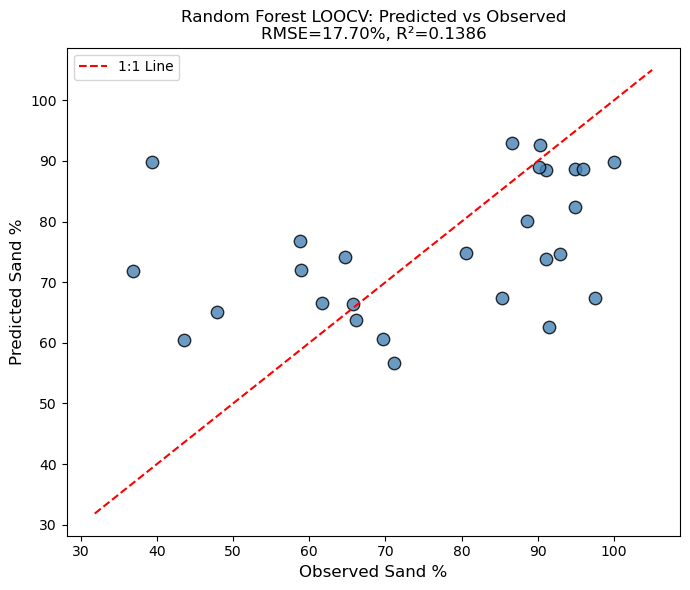

In [26]:

# =====================================================================
# CELL 12: Stage 2 — Random Forest Regression with LOOCV
# =====================================================================
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import LeaveOneOut
from sklearn.metrics import mean_squared_error, r2_score, mean_absolute_error

# Features and target
feature_cols = ['B2', 'B3', 'B4', 'B8', 'B11']
X = df_spectral[feature_cols].values
y = df_spectral['Sand_Pct'].values

# --- Leave-One-Out Cross-Validation ---
loo = LeaveOneOut()
y_true_list, y_pred_list = [], []

print("🔄 Running Leave-One-Out Cross-Validation...")
for train_idx, test_idx in loo.split(X):
    X_train, X_test = X[train_idx], X[test_idx]
    y_train, y_test = y[train_idx], y[test_idx]

    rf = RandomForestRegressor(n_estimators=200, max_depth=None,
                               min_samples_split=2, random_state=42)
    rf.fit(X_train, y_train)
    pred = rf.predict(X_test)

    y_true_list.append(y_test[0])
    y_pred_list.append(pred[0])

y_true_arr = np.array(y_true_list)
y_pred_arr = np.array(y_pred_list)

# --- Metrics ---
rmse = np.sqrt(mean_squared_error(y_true_arr, y_pred_arr))
mae  = mean_absolute_error(y_true_arr, y_pred_arr)
r2   = r2_score(y_true_arr, y_pred_arr)

print(f"\n{'='*50}")
print(f"📊 LOOCV Regression Results")
print(f"{'='*50}")
print(f"  RMSE : {rmse:.2f}%")
print(f"  MAE  : {mae:.2f}%")
print(f"  R²   : {r2:.4f}")
print(f"{'='*50}")

# --- Scatter Plot: Predicted vs Observed ---
plt.figure(figsize=(7, 6))
plt.scatter(y_true_arr, y_pred_arr, c='steelblue', edgecolors='k', s=80, alpha=0.8)
# 1:1 line
lims = [min(y_true_arr.min(), y_pred_arr.min()) - 5,
        max(y_true_arr.max(), y_pred_arr.max()) + 5]
plt.plot(lims, lims, 'r--', linewidth=1.5, label='1:1 Line')
plt.xlabel('Observed Sand %', fontsize=12)
plt.ylabel('Predicted Sand %', fontsize=12)
plt.title(f'Random Forest LOOCV: Predicted vs Observed\nRMSE={rmse:.2f}%, R²={r2:.4f}')
plt.legend()
plt.tight_layout()
plt.show()



--- Feature Importances ---
  B2 (Blue): 11.02%
  B3 (Green): 14.59%
  B4 (Red): 20.43%
  B8 (NIR): 37.63%
  B11 (SWIR): 16.34%


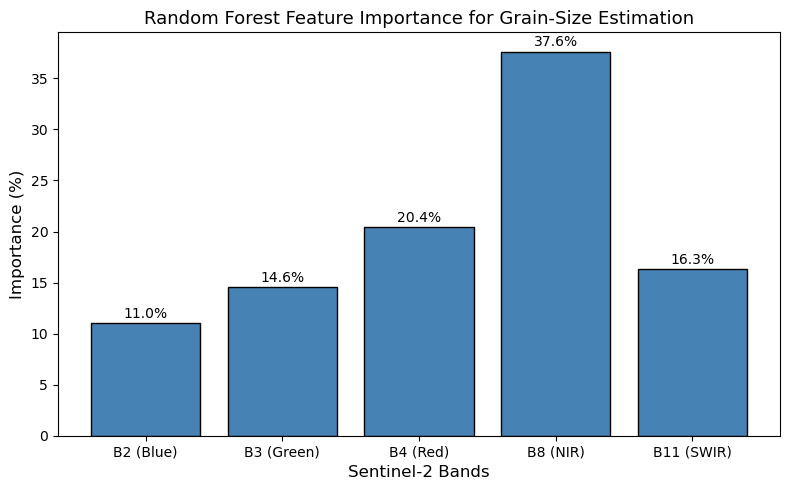

In [27]:

# =====================================================================
# CELL 13: Stage 2 — Feature Importance Analysis
# =====================================================================

# Retrain on the full dataset for final feature importances
rf_final = RandomForestRegressor(n_estimators=200, random_state=42)
rf_final.fit(X, y)
importances = rf_final.feature_importances_

band_labels = ['B2 (Blue)', 'B3 (Green)', 'B4 (Red)', 'B8 (NIR)', 'B11 (SWIR)']

print("\n--- Feature Importances ---")
for name, imp in zip(band_labels, importances):
    print(f"  {name}: {imp * 100:.2f}%")

# Bar chart
plt.figure(figsize=(8, 5))
bars = plt.bar(band_labels, importances * 100, color='steelblue', edgecolor='black')
plt.title("Random Forest Feature Importance for Grain-Size Estimation", fontsize=13)
plt.ylabel("Importance (%)", fontsize=12)
plt.xlabel("Sentinel-2 Bands", fontsize=12)

# Annotate bars
for bar, imp in zip(bars, importances):
    plt.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.5,
             f'{imp*100:.1f}%', ha='center', fontsize=10)

plt.tight_layout()
plt.show()


✅ Saved: loocv_scatter.jpg


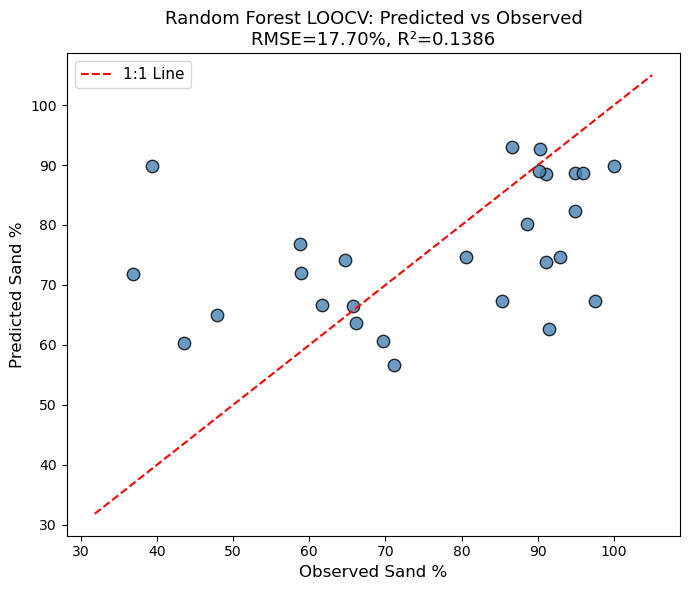

✅ Saved: feature_importance.jpg


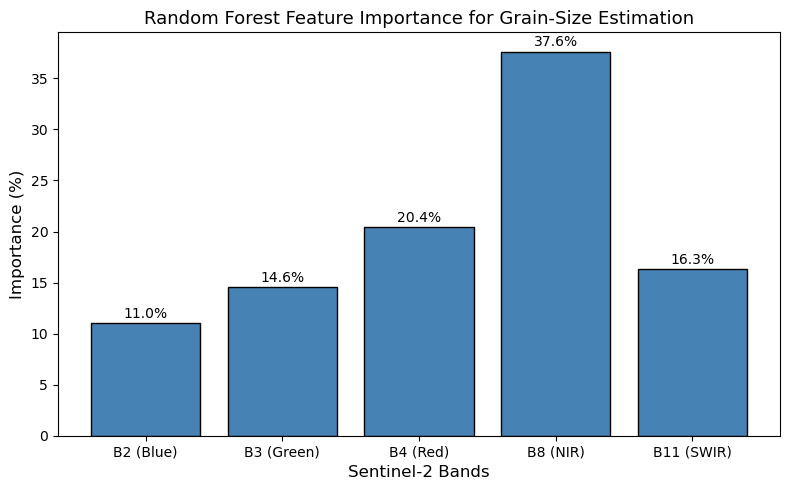


📍 Test image 1: scene_12_image.tif (421×533)
✅ Saved: deeplab_pred_with_samples_1.jpg (27 sample points)
✅ Saved: deeplab_pred_with_samples_1.jpg (27 sample points)


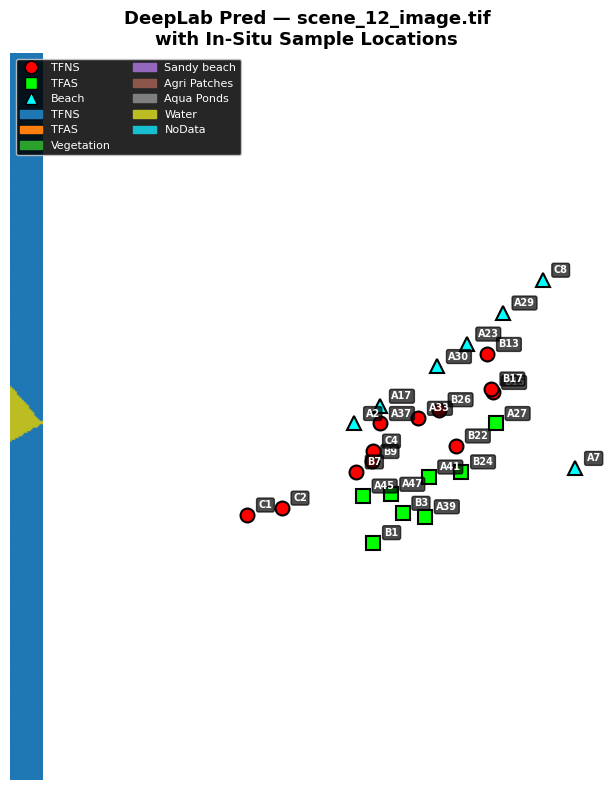


📍 Test image 2: scene_06_image.tif (494×601)
✅ Saved: deeplab_pred_with_samples_2.jpg (27 sample points)
✅ Saved: deeplab_pred_with_samples_2.jpg (27 sample points)


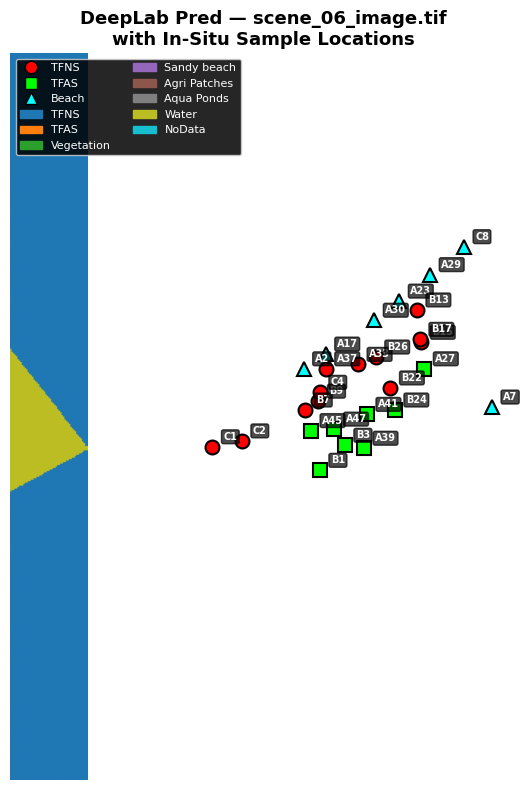


📍 Test image 3: scene_01 _image.tif (422×533)
✅ Saved: deeplab_pred_with_samples_3.jpg (27 sample points)
✅ Saved: deeplab_pred_with_samples_3.jpg (27 sample points)


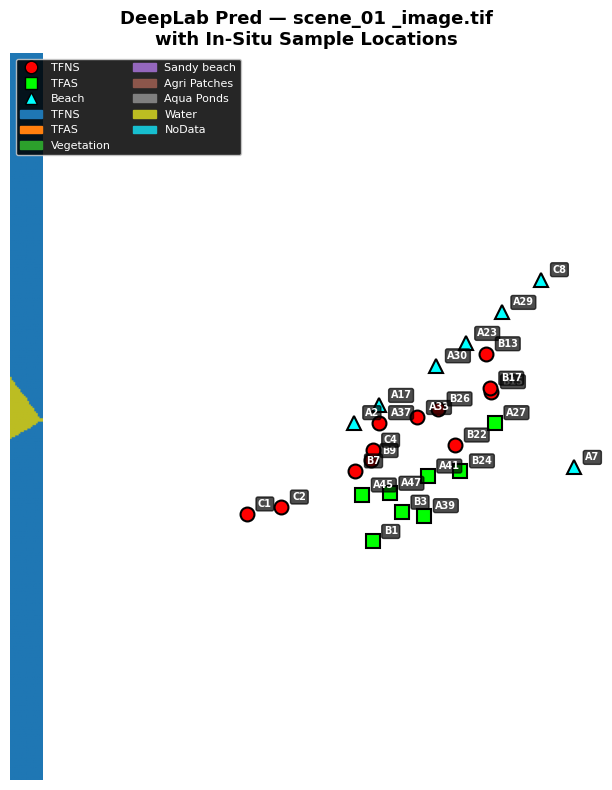


📊 Stage 2 Regression Summary
  Samples used : 27 (TFNS + TFAS + Beach)
  Features     : B2, B3, B4, B8, B11
  Model        : Random Forest (n_estimators=200)
  Validation   : Leave-One-Out Cross-Validation
  RMSE         : 17.70%
  MAE          : 13.59%
  R²           : 0.1386

Top feature: B8 (NIR) (37.6%)


In [31]:

# =====================================================================
# CELL 18: Stage 2 — Visualize Results & Save as JPG
# =====================================================================
import matplotlib.patches as mpatches
from pyproj import Transformer as ProjTransformer

SAVE_DIR = '/Users/SONY/Documents/College/Study_pdeu/Res_Paper/AI/Poojamaam/Data/unet'

# --- 1. Scatter Plot: Predicted vs Observed (LOOCV) ---
fig1, ax1 = plt.subplots(figsize=(7, 6))
ax1.scatter(y_true_arr, y_pred_arr, c='steelblue', edgecolors='k', s=80, alpha=0.8)
lims = [min(y_true_arr.min(), y_pred_arr.min()) - 5,
        max(y_true_arr.max(), y_pred_arr.max()) + 5]
ax1.plot(lims, lims, 'r--', linewidth=1.5, label='1:1 Line')
ax1.set_xlabel('Observed Sand %', fontsize=12)
ax1.set_ylabel('Predicted Sand %', fontsize=12)
ax1.set_title(f'Random Forest LOOCV: Predicted vs Observed\nRMSE={rmse:.2f}%, R²={r2:.4f}', fontsize=13)
ax1.legend(fontsize=11)
fig1.tight_layout()
fig1.savefig(os.path.join(SAVE_DIR, 'loocv_scatter.jpg'), dpi=300, bbox_inches='tight')
print(f"✅ Saved: loocv_scatter.jpg")
plt.show()

# --- 2. Feature Importance Bar Chart ---
band_labels = ['B2 (Blue)', 'B3 (Green)', 'B4 (Red)', 'B8 (NIR)', 'B11 (SWIR)']
fig2, ax2 = plt.subplots(figsize=(8, 5))
bars = ax2.bar(band_labels, importances * 100, color='steelblue', edgecolor='black')
ax2.set_title("Random Forest Feature Importance for Grain-Size Estimation", fontsize=13)
ax2.set_ylabel("Importance (%)", fontsize=12)
ax2.set_xlabel("Sentinel-2 Bands", fontsize=12)
for bar, imp in zip(bars, importances):
    ax2.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.5,
             f'{imp*100:.1f}%', ha='center', fontsize=10)
fig2.tight_layout()
fig2.savefig(os.path.join(SAVE_DIR, 'feature_importance.jpg'), dpi=300, bbox_inches='tight')
print(f"✅ Saved: feature_importance.jpg")
plt.show()

# --- 3. Sample Points on DeepLab Predicted Segmentation (test patches) ---
# Reproduce exact train/test split
image_files_all = sorted([os.path.join(IMAGE_DIR, f) for f in os.listdir(IMAGE_DIR) if f.endswith('.tif')])
mask_files_all  = sorted([os.path.join(MASK_DIR, f)  for f in os.listdir(MASK_DIR)  if f.endswith('.tif')])
paired = list(zip(image_files_all, mask_files_all))
_, test_val_split = train_test_split(paired, test_size=0.3, random_state=42)
_, test_files_split = train_test_split(test_val_split, test_size=0.5, random_state=42)

# Coordinate transformer
proj_transformer = ProjTransformer.from_crs("EPSG:4326", "EPSG:32645", always_xy=True)

# Color/marker config for sub-environments
env_colors  = {'TFNS': 'red', 'TFAS': 'lime', 'Beach': 'cyan'}
env_markers = {'TFNS': 'o', 'TFAS': 's', 'Beach': '^'}

cmap_seg = plt.get_cmap('tab10', NUM_CLASSES)
class_names_seg = ["TFNS", "TFAS", "Vegetation", "Sandy beach",
                   "Agri Patches", "Aqua Ponds", "Water", "NoData"]

# Process each test image individually (load from file → predict → overlay)
for i, (img_path, msk_path) in enumerate(test_files_split):
    # Read the image directly from the .tif file
    with rasterio.open(img_path) as src:
        raw_image = src.read().astype(np.float32)          # (bands, H, W)
        raw_image = np.transpose(raw_image, (1, 2, 0))     # (H, W, bands)
        geo_transform = src.transform
        orig_h, orig_w = src.height, src.width

    print(f"\n📍 Test image {i+1}: {os.path.basename(img_path)} ({orig_h}×{orig_w})")

    # Pad to model input size and normalise (same as load_and_preprocess)
    input_img = tf.image.resize_with_pad(raw_image, IMG_HEIGHT, IMG_WIDTH)
    input_img = input_img / 65535.0
    input_batch = tf.expand_dims(input_img, 0)

    # Run DeepLab prediction
    pred = deeplab_model.predict(input_batch, verbose=0)
    pred_mask = np.argmax(pred[0], axis=-1)   # (IMG_HEIGHT, IMG_WIDTH)

    # Crop back to the image's own original size (remove padding)
    h_pad = (IMG_HEIGHT - orig_h) // 2
    w_pad = (IMG_WIDTH  - orig_w) // 2
    deep_crop = pred_mask[h_pad:h_pad+orig_h, w_pad:w_pad+orig_w]

    # --- Plot the DeepLab predicted segmentation ---
    fig, ax = plt.subplots(figsize=(10, 8))
    ax.imshow(deep_crop, cmap=cmap_seg, vmin=0, vmax=7)
    ax.set_title(f"DeepLab Pred — {os.path.basename(img_path)}\nwith In-Situ Sample Locations",
                 fontsize=13, fontweight='bold')
    ax.axis("off")

    # Overlay sample points (convert lon/lat → pixel in this patch)
    plotted = 0
    for _, srow in grain_size_data.iterrows():
        x_utm, y_utm = proj_transformer.transform(srow['Longitude'], srow['Latitude'])
        col_px, row_px = ~geo_transform * (x_utm, y_utm)
        col_px, row_px = int(col_px), int(row_px)

        # Check if point falls within this patch
        if 0 <= row_px < orig_h and 0 <= col_px < orig_w:
            env = srow['Sub_env']
            color = env_colors.get(env, 'white')
            marker = env_markers.get(env, 'o')
            ax.plot(col_px, row_px, marker=marker, color=color,
                    markersize=10, markeredgecolor='black', markeredgewidth=1.5)
            ax.annotate(srow['Sample_ID'], (col_px, row_px),
                        textcoords="offset points", xytext=(8, 5),
                        fontsize=7, color='white', fontweight='bold',
                        bbox=dict(boxstyle='round,pad=0.2', fc='black', alpha=0.7))
            plotted += 1

    # Legends
    env_handles = [plt.Line2D([0], [0], marker=env_markers[e], color=env_colors[e],
                   linestyle='', markersize=9, markeredgecolor='black', label=e)
                   for e in ['TFNS', 'TFAS', 'Beach']]
    seg_handles = [mpatches.Patch(color=cmap_seg(j), label=class_names_seg[j])
                   for j in range(NUM_CLASSES)]
    ax.legend(handles=env_handles + seg_handles, loc='upper left', fontsize=8,
              facecolor='black', labelcolor='white', framealpha=0.85, ncol=2)

    fig.tight_layout()
    save_name = f'deeplab_pred_with_samples_{i+1}.jpg'
    fig.savefig(os.path.join(SAVE_DIR, save_name), dpi=300, bbox_inches='tight')
    print(f"✅ Saved: {save_name} ({plotted} sample points)")
    plt.show()

# --- 4. Summary Table ---
print(f"\n{'='*50}")
print(f"📊 Stage 2 Regression Summary")
print(f"{'='*50}")
print(f"  Samples used : {len(df_spectral)} (TFNS + TFAS + Beach)")
print(f"  Features     : B2, B3, B4, B8, B11")
print(f"  Model        : Random Forest (n_estimators=200)")
print(f"  Validation   : Leave-One-Out Cross-Validation")
print(f"  RMSE         : {rmse:.2f}%")
print(f"  MAE          : {mae:.2f}%")
print(f"  R²           : {r2:.4f}")
print(f"{'='*50}")
print(f"\nTop feature: {band_labels[np.argmax(importances)]} ({importances.max()*100:.1f}%)")
